# Импорт библиотек

In [513]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# EDA

In [447]:
df = pd.read_excel('data/result2022.xlsx')

In [448]:
df.head()

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,0.00,0.00,61.28,48.28,0,0,0,0.0,8.34,8.34,...,80.76,4.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2022
1,51.69,51.69,51.48,39.26,0,0,0,0.0,0.00,0.00,...,66.01,11.19,34.13,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2022
2,0.00,0.00,0.00,0.00,0,0,0,0.0,0.00,0.00,...,97.58,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2022
3,0.00,0.00,55.70,55.70,0,0,0,0.0,0.00,0.00,...,68.66,1.53,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2022
4,0.00,0.00,0.00,0.00,0,0,0,0.0,100.00,100.00,...,9.09,85.08,9.77,12.17,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2022


Посмотрим размер датасета

In [449]:
df.shape

(681, 133)

Быстрый обзор типов/пропусков

In [450]:
df.dtypes.head(30)

Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ                                                                                                                                                                                                                                                                                                        float64
Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема                                                                                                                                                                                  float64
Средний балл ЕГЭ сту

Нужна нормализация названия столбцов, произведем ее

In [451]:
col_rename = {
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ": "ege_avg_budget_full_time",
    "Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема": "ege_avg_budget_full_time_no_special_rights_no_target_quota",
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами": "ege_avg_paid_full_time",
    "Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета": "ege_min_avg_full_time",
    "Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний": "olympiad_final_winners_admitted_no_exams",
    "Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний": "school_olympiad_winners_admitted_no_exams",
    "Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета": "target_admission_count_full_time",
    "Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения": "target_admission_share_full_time",
    "Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры": "masters_share_in_total_contingent",
    "Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования": "postgrad_and_residency_share_in_total_contingent",
    "Удельный вес численности студентов, имеющих диплом бакалавра, специалиста или магистра других организаций, принятых на первый курс на обучение по программам магистратуры образовательной организации, в общей численности студентов, принятых на первый курс по программам магистратуры на очную форму обучения": "masters_admitted_from_other_orgs_share_full_time",
    "Удельный вес численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки": "postgrad_from_other_orgs_share",
    "Численность аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в расчете на 100 студентов (приведенного контингента)": "postgrad_per_100_students",
    "Удельный вес численности слушателей из сторонних организаций в общей численности слушателей, прошедших обучение в образовательной организации по программам повышения квалификации или профессиональной переподготовки": "dpo_external_listeners_share",
    "Удельный вес численности студентов, обучающихся по направлениям подготовки бакалавриата, специалитета, и магистратуры по областям знаний «Инженерное дело, технологии и технические науки», «Здравоохранение и медицинские науки», «Образование и педагогические науки», с которыми заключены договоры о целевом обучении, в общей численности студентов, обучающихся по указанным областям знаний": "target_contract_share_priority_fields",

    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection в расчете на 100 НПР[н]": "citations_wos_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Scopus в расчете на 100 НПР[н]": "citations_scopus_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в Российском индексе научного цитирования (далее – РИНЦ) в расчете на 100 НПР[н]": "citations_rinc_5y_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection, в расчете на 100 НПР[н]": "publications_wos_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Scopus, в расчете на 100 НПР[н]": "publications_scopus_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования РИНЦ, в расчете на 100 НПР[н]": "publications_rinc_per_100_faculty",
    "Общий объем научно-исследовательских и опытно-конструкторских работ (далее – НИОКР)": "rnd_total_volume",
    "Удельный вес доходов от НИОКР в общих доходах образовательной организации": "rnd_income_share_total",
    "Удельный вес НИОКР, выполненных собственными силами (без привлечения соисполнителей), в общих доходах образовательной организации от НИОКР": "rnd_own_work_share_in_rnd_income",
    "Доходы от НИОКР (за исключением средств бюджетов бюджетной системы Российской Федерации, государственных фондов поддержки науки) в расчете на одного НПР[н]": "rnd_income_per_faculty_excl_budget",
    "Количество лицензионных соглашений": "license_agreements_count",
    "Удельный вес средств, полученных образовательной организацией от использования результатов интеллектуальной деятельности, в общих доходах образовательной организации": "rid_income_share_total",
    "Удельный вес численности НПР без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности НПР[н]": "young_faculty_share",
    "Удельный вес научно-педагогических работников, защитивших кандидатские и докторские диссертации за отчетный период в общей численности НПР": "defended_theses_share",
    "Количество научных журналов, в том числе электронных, издаваемых образовательной организацией": "journals_count",
    "Количество полученных грантов за отчетный год в расчете на 100 НПР[н]": "grants_per_100_faculty",

    "Удельный вес численности иностранных студентов (кроме стран Содружества Независимых Государств (далее – СНГ)), обучающихся программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_non_cis_share",
    "Удельный вес численности иностранных студентов из СНГ, обучающихся по программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_cis_share",
    "Удельный вес численности иностранных студентов, завершивших освоение образовательных программ бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_share",
    "Удельный вес численности иностранных студентов (кроме стран СНГ), завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_non_cis_share",
    "Удельный вес численности иностранных студентов из стран СНГ, завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_cis_share",
    "Удельный вес численности студентов, обучающихся по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, прошедших обучение за рубежом не менее семестра (триместра), в общей численности студентов, обучающихся по очной форме обучения": "outbound_mobility_semester_share",
    "Численность студентов иностранных образовательных организаций, прошедших обучение в образовательной организации по образовательным по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, не менее семестра (триместра) в расчете на 100 студентов, обучающихся по очной форме обучения": "inbound_mobility_per_100_students",
    "Удельный вес численности иностранных граждан из числа НПР в общей численности НПР": "foreign_faculty_share",
    "Численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих (работавших) в образовательной организации не менее 1 семестра": "visiting_professors_count",
    "Удельный вес численности иностранных граждан (кроме стран СНГ) из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_non_cis_share",
    "Удельный вес численности иностранных граждан из стран СНГ из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_cis_share",
    "Объем средств, полученных образовательной организацией от выполнения НИОКР от иностранных граждан и иностранных юридических лиц": "rnd_funds_from_foreign_entities",
    "Объем средств от образовательной деятельности, полученных образовательной организацией от иностранных граждан и иностранных юридических лиц": "edu_funds_from_foreign_entities",

    "Доходы образовательной организации из средств от приносящей доход деятельности в расчете на одного НПР": "income_nonbudget_per_faculty",
    "Доля доходов из средств от приносящей доход деятельности в доходах по всем видам финансового обеспечения (деятельности) образовательной организации": "income_nonbudget_share_total",
    "Отношение средней заработной платы НПР в образовательной организации (из всех источников) к средней заработной плате по экономике региона": "faculty_salary_to_region_avg_ratio",
    "Доходы образовательной организации из всех источников в расчете на численность студентов (приведенный контингент)": "income_per_student",
    "Общая площадь учебно-лабораторных помещений в расчете на одного студента (приведенного контингента),в том числе:": "teaching_lab_area_per_student_total",
    "имеющихся на праве собственности": "teaching_lab_area_owned",
    "закрепленных на праве оперативного управления": "teaching_lab_area_operational",
    "предоставленных в безвозмездное пользование": "teaching_lab_area_free_use",
    "предоставленных в аренду": "teaching_lab_area_rented",
    "Количество персональных компьютеров в расчете на одного студента (приведенного контингента)": "pcs_per_student",
    "Удельный вес стоимости машин и оборудования (не старше 5 лет) в общей стоимости машин и оборудования": "equipment_under_5y_value_share",
    "Количество экземпляров печатных учебных изданий (включая учебники и учебные пособия) из общего количества единиц хранения библиотечного фонда, состоящих на учете, в расчете на одного студента (приведенного контингента)": "printed_textbooks_per_student",
    "Удельный вес НПР, имеющих ученую степень кандидата наук, в общей численности НПР": "faculty_phd_share",
    "Удельный вес НПР имеющих ученую степень доктора наук, в общей численности НПР": "faculty_dsc_share",
    "Удельный вес НПР, имеющих ученую степень кандидата и доктора наук, в общей численности НПР образовательной организации (без совместителей и работающих по договорам гражданско-правового характера)": "faculty_phd_dsc_share",
    "Число НПР, имеющих ученую степень кандидата и доктора наук, в расчете на 100 студентов": "faculty_phd_dsc_per_100_students",
    "Доля штатных работников ППС в общей численности ППС": "faculty_staff_share",

    "2": "section_2",
    "Образовательная деятельность": "section_education",
    "Общая численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "students_total",
    "в том числе:по очной форме обучения": "students_full_time",
    "по очно-заочной (вечерней) форме обучения": "students_part_time_evening",
    "по заочной форме обучения": "students_correspondence",
    "Средний балл ЕГЭ студентов, принятых на обучение по программам бакалавриата и специалитета, по всем формам обучения": "ege_avg_all_forms",
    "Доля обучающихся по программам бакалавриата, специалитета, магистратуры в очной форме": "share_full_time",
    "Доля обучающихся по программам бакалавриата в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_bachelor_in_total",
    "Доля обучающихся по программам магистратуры в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_master_in_total",
    "Общая численность слушателей программ дополнительного профессионального образования": "dpo_listeners_total",
    "Общая численность обучающихся по программам среднего профессионального образования": "spo_students_total",
    "Число предприятий, с которыми заключены договоры на подготовку специалистов": "partner_enterprises_count",
    "Число предприятий, являющихся базами практики, с которыми оформлены договорные отношения": "practice_bases_count",

    "Научная деятельность": "section_research",
    "Общий объем средств, поступивших (за отчетный год) от выполнения НИОКР, выполненных собственными силами": "rnd_funds_own_total",
    "Общий объем средств, поступивших (за отчетный год) от выполнения работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами": "research_services_funds_own_total",
    "Общее количество публикаций организации в расчете на 100 НПР": "publications_total_per_100_faculty",
    "Количество бизнес-инкубаторов": "incubators_count",
    "Количество технопарков": "technoparks_count",
    "Количество центров коллективного пользования научным оборудованием": "shared_equipment_centers_count",
    "Количество малых предприятий": "small_enterprises_count",
    "Общая численность аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "postgrads_total",
    "Доля аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров, обучающихся в очной форме": "postgrads_full_time_share",
    "Общая численность докторантов": "doctoral_students_total",
    "Число диссертационных советов": "dissertation_councils_count",

    "Кадровый потенциал": "section_hr",
    "Общая численность работников образовательной организации (без внешних совместителей и работающих по договорам ГПХ)": "employees_total",
    "Общая численность ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_total",
    "Общая численность научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_total",
    "Доля ППС, имеющих ученые степени": "faculty_degree_share",
    "Доля научных работников, имеющих ученые степени": "researchers_degree_share",
    "Доля ППС возрастной категории моложе 65 лет": "faculty_under_65_share",
    "Доля ППС возрастной категории моложе 40 лет": "faculty_under_40_share",
    "Средняя заработная плата ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_avg_salary",
    "Средняя заработная плата научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_avg_salary",

    "Международная деятельность": "section_international",
    "Общая численность иностранных студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_total",
    "Доля иностранных студентов в общей численности студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_share_total",
    "Общее число образовательных программ высшего образования, реализуемых совместно с зарубежными вузами и ведущих к получению двух дипломов": "double_degree_programs_count",
    "Общая численность обучающихся по очной форме обучения по программам бакалавриата, специалитета, магистратуры, реализуемым совместно с зарубежными вузами и ведущим к получению двух дипломов": "double_degree_students_full_time_total",
    "Общая численность иностранных аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "foreign_postgrads_total",
    "Число статей, подготовленных совместно с зарубежными организациями": "intl_coauthored_articles_count",
    "Доходы вуза из иностранных источников на выполнение НИОКР": "rnd_income_foreign_sources",
    "Доходы вуза от образовательной деятельности из иностранных источников": "edu_income_foreign_sources",
    "Количество созданных результатов интеллектуальной деятельности, имеющих правовую охрану за пределами России": "rid_protected_abroad_count",

    "Инфраструктура": "section_infrastructure",
    "Общая площадь зданий (помещений)": "buildings_area_total",
    "Площадь учебно-лабораторных зданий": "teaching_lab_buildings_area",
    "Площадь, предназначенная для научно-исследовательских подразделений": "research_units_area",
    "Площадь общежитий": "dorms_area",
    "Площадь крытых спортивных сооружений": "indoor_sports_area",
    "Доля студентов, не обеспеченных собственным общежитием, в числе студентов, нуждающихся в общежитии": "dorm_shortage_share",
    "Количество персональных компьютеров": "pcs_total",
    "Доля персональных компьютеров, имеющих доступ к Интернету": "pcs_internet_share",
    "Наличие электронной библиотечной системы": "has_e_library_system",

    "Финансово-экономическая деятельность": "section_finance",
    "Доходы вуза из всех источников": "income_total",
    "Доходы вуза из внебюджетных источников": "income_nonbudget",
    "Доля доходов вуза из внебюджетных источников": "income_nonbudget_share",
    "Доля доходов вуза из федерального бюджета": "income_federal_budget_share",
    "Доля доходов вуза из бюджета субъекта РФ и местного бюджета": "income_regional_local_budget_share",
    "Доля доходов вуза от образовательной деятельности в общих доходах вуза": "income_edu_share_total",
    "Доля доходов вуза от научных исследований и разработок в общих доходах вуза": "income_research_share_total",
    "Доля внебюджетных средств в доходах от образовательной деятельности": "nonbudget_share_in_edu_income",
    "Доля внебюджетных средств в доходах от научных исследований и разработок": "nonbudget_share_in_research_income",

    "VUZ": "vuz",
    "Region": "region",
    "Type": "type",
    "Site": "site",
    "ID": "id",
    "year": "year",
}

In [452]:
df = df.rename(columns=col_rename)

In [453]:
df.head()

,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_target_quota,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,postgrad_and_residency_share_in_total_contingent,...,income_edu_share_total,income_research_share_total,nonbudget_share_in_edu_income,nonbudget_share_in_research_income,vuz,region,type,site,id,year
0,0.00,0.00,61.28,48.28,0,0,0,0.0,8.34,8.34,...,80.76,4.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2022
1,51.69,51.69,51.48,39.26,0,0,0,0.0,0.00,0.00,...,66.01,11.19,34.13,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2022
2,0.00,0.00,0.00,0.00,0,0,0,0.0,0.00,0.00,...,97.58,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2022
3,0.00,0.00,55.70,55.70,0,0,0,0.0,0.00,0.00,...,68.66,1.53,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2022
4,0.00,0.00,0.00,0.00,0,0,0,0.0,100.00,100.00,...,9.09,85.08,9.77,12.17,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2022


In [454]:
df = df.drop('id', axis=1)

In [455]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Columns: 132 entries, ege_avg_budget_full_time to year
dtypes: float64(90), int64(38), object(4)
memory usage: 702.4+ KB


Посмотрим на 4 колонки с типом object

In [456]:
df.select_dtypes(include='object')

,vuz,region,type,site
0,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru
1,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru
2,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/
3,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/
4,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru
...,...,...,...,...
676,федеральное государственное бюджетное образова...,Приморский край,Министерство здравоохранения Российской Федерации,https://tgmu.ru/
677,Федеральное государственное бюджетное образова...,Хабаровский край,Министерство науки и высшего образования Росси...,http://pnu.edu.ru
678,федеральное государственное бюджетное образова...,Хабаровский край,Министерство культуры Российской Федерации,http://www.hgiik.ru
679,Частное образовательное учреждение высшего обр...,Республика Бурятия,Частные образовательные организации,bepi-edu.ru


## Дубликаты

In [457]:
dup_rows = df.duplicated().sum()
dup_rows

0

## Пропуски

In [458]:
miss = (
    df.isna().mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .to_frame("missing_%")
)
miss.head(30)

,missing_%
publications_wos_per_100_faculty,100.0
citations_wos_5y_per_100_faculty,100.0
section_infrastructure,100.0
section_hr,100.0
has_e_library_system,100.0
publications_scopus_per_100_faculty,100.0
section_finance,100.0
citations_scopus_5y_per_100_faculty,100.0
section_international,100.0
section_research,100.0


Присутствуют пропуски и они 100% можно просто убрать эти столбцы

In [459]:
df = df.drop(['publications_scopus_per_100_faculty', 'section_infrastructure', 'section_finance', 'publications_wos_per_100_faculty', 'section_hr', 'citations_scopus_5y_per_100_faculty', 'citations_wos_5y_per_100_faculty', 'has_e_library_system', 'section_education', 'section_research', 'section_international'], axis=1)

## Константные / почти константные колонки

In [460]:
nunique = df.nunique(dropna=False).sort_values()
const_cols = nunique[nunique <= 1]
print("Константные колонки:", len(const_cols))
if len(const_cols):
    for col in const_cols.index:
        print(f"\nКолонка: {col}")
        print(f"Уникальные значения: {df[col].unique()}")
        print(f"Количество NaN: {df[col].isna().sum()}")

Константные колонки: 2

Колонка: year
Уникальные значения: [2022]
Количество NaN: 0

Колонка: section_2
Уникальные значения: [4]
Количество NaN: 0


In [461]:
near_const = []
for c in df.columns:
    vc = df[c].value_counts(dropna=False)
    if len(vc) == 0:
        continue
    if (vc.iloc[0] / len(df)) >= 0.99:
        near_const.append((c, float(vc.iloc[0] / len(df))))
near_const = sorted(near_const, key=lambda x: x[1], reverse=True)
print("Почти константные признаки:", len(near_const))
pd.DataFrame(near_const, columns=["col", "top_share"]).head(30)

Почти константные признаки: 2


,col,top_share
0,section_2,1.0
1,year,1.0


Удалим данные константные колонки

In [462]:
df = df.drop(['section_2', 'year'], axis=1)

In [463]:
df.shape

(681, 119)

## Описательная статистика

### Числовые

In [464]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [465]:
desc = df[num_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc.sort_values("std", ascending=False).head(30)

,count,mean,std,min,1%,5%,50%,95%,99%,max
income_total,681.0,1.544827e+06,3.053261e+06,62.00,4515.200,15500.00,689929.50,6024791.20,1.373365e+07,38320205.20
income_nonbudget,681.0,6.509417e+05,1.426923e+06,0.00,2751.520,10302.50,211070.10,2608756.30,6.858942e+06,15899410.50
research_services_funds_own_total,681.0,1.713239e+05,5.405918e+05,0.00,0.000,0.00,26708.80,858078.40,2.341808e+06,7566786.00
rnd_total_volume,681.0,1.710789e+05,5.395120e+05,0.00,0.000,0.00,27722.60,810576.00,2.374154e+06,7752989.00
rnd_funds_own_total,681.0,1.595528e+05,5.135417e+05,0.00,0.000,0.00,25058.20,783076.00,2.222736e+06,7566786.00
buildings_area_total,681.0,8.422733e+04,1.249793e+05,0.00,512.200,1666.00,52823.00,252815.00,5.751948e+05,1662182.00
edu_funds_from_foreign_entities,681.0,3.362995e+04,1.100230e+05,0.00,0.000,0.00,1794.30,167843.90,5.577539e+05,1717091.10
edu_income_foreign_sources,681.0,3.362995e+04,1.100230e+05,0.00,0.000,0.00,1794.30,167843.90,5.577539e+05,1717091.10
teaching_lab_buildings_area,681.0,5.439200e+04,7.486633e+04,0.00,512.200,1554.00,35036.00,166366.00,3.156436e+05,987056.00
dorms_area,681.0,2.137683e+04,3.274089e+04,0.00,0.000,0.00,12925.00,71675.00,1.403678e+05,359113.00


Выводы:
- Почти все финансовые и инфраструктурные показатели имеют среднее значительно выше медианы, очень большие 95–99 перцентили, огромной разрыв между min и max
- printed_textbooks_per_student – максимум в 300 раз больше медианы
- citations_rinc_5y_per_100_faculty – очень сильная асимметрия, но это возможная ситуация
- income_total vs income_nonbudget – в среднем внебюджет ≈ 42% от total, но распределение неравномерное
- R&D показатели – более 50% вузов не имеют иностранных R&D доходов (медиана = 0)
- студенты – есть крупные университеты, но значительная часть — средние и малые.
- иностранные студенты – часть вузов вообще не работает с иностранцами
- инфрастуктура – площадь вузов отличается более чем в 30 раз от медианы, 50% вузов имеют общежития
- income_per_student, rnd_income_per_faculty_excl_budget, income_nonbudget_per_faculty – показатели имеют сильную асимметрию

Посмотрим на выбросы

In [466]:
def iqr_stats(s):
    s = s.dropna()
    if len(s) < 5:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).mean()
    return outliers

In [467]:
iqr_results = []

for c in num_cols:
    share = iqr_stats(df[c])
    iqr_results.append((c, share))

iqr_df = pd.DataFrame(iqr_results, columns=["column", "outlier_share"])
iqr_df.sort_values("outlier_share", ascending=False).head(30)

,column,outlier_share
1,ege_avg_budget_full_time_no_special_rights_no_...,0.243759
91,double_degree_programs_count,0.237885
0,ege_avg_budget_full_time,0.236417
42,faculty_salary_to_region_avg_ratio,0.233480
48,teaching_lab_area_rented,0.220264
92,double_degree_students_full_time_total,0.215859
72,incubators_count,0.211454
95,rnd_income_foreign_sources,0.209985
38,rnd_funds_from_foreign_entities,0.209985
5,school_olympiad_winners_admitted_no_exams,0.186490


Вывод:
- Довольно большие доли выбросов, но это скорее всего реальные данные и их нужно немного преобразовать

Посмотрим на ассиметрии

In [468]:
df[num_cols].skew().sort_values(ascending=False).head(20)

teaching_lab_area_free_use                  22.735288
defended_theses_share                       22.609292
researchers_total                           20.712987
faculty_phd_dsc_per_100_students            20.321835
double_degree_students_full_time_total      19.739178
printed_textbooks_per_student               18.203626
outbound_mobility_semester_share            18.126194
teaching_lab_area_owned                     18.089714
teaching_lab_area_rented                    15.573312
pcs_per_student                             15.338134
foreign_postgrads_total                     15.189386
olympiad_final_winners_admitted_no_exams    14.930794
rid_income_share_total                      14.383573
rid_protected_abroad_count                  13.921888
income_per_student                          13.216800
faculty_avg_salary                          12.868272
license_agreements_count                    12.029647
teaching_lab_area_per_student_total         11.835253
dissertation_councils_count 

Вывод:
- skewness > 11 — это экстремальная правосторонняя асимметрия
- логарифмирование почти обязательно или использование моделей, устойчивых к skew

Посмотрим корреляции

In [469]:
corr = df[num_cols].corr()

In [470]:
pairs = []
cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if pd.notna(val):
            pairs.append((cols[i], cols[j], val, abs(val)))

corr_pairs = pd.DataFrame(pairs, columns=["col1", "col2", "corr", "abs_corr"])
corr_pairs.sort_values("abs_corr", ascending=False).head(50)

,col1,col2,corr,abs_corr
1992,rnd_income_share_total,income_research_share_total,1.000000,1.000000
3685,rnd_funds_from_foreign_entities,rnd_income_foreign_sources,1.000000,1.000000
3761,edu_funds_from_foreign_entities,edu_income_foreign_sources,1.000000,1.000000
3920,income_nonbudget_share_total,income_nonbudget_share,1.000000,1.000000
1853,rnd_total_volume,rnd_funds_own_total,0.997108,0.997108
5520,rnd_funds_own_total,research_services_funds_own_total,0.993054,0.993054
1854,rnd_total_volume,research_services_funds_own_total,0.990445,0.990445
5960,employees_total,faculty_total,0.963077,0.963077
0,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_...,0.962754,0.962754
6419,buildings_area_total,teaching_lab_buildings_area,0.960476,0.960476


Вывод:
- абсолютная линейная зависимость у rnd_income_share_total — income_research_share_total,rnd_funds_from_foreign_entities — rnd_income_foreign_sources, edu_funds_from_foreign_entities — edu_income_foreign_sources, income_nonbudget_share_total — income_nonbudget_share. Надо будет убрать один из признаков пар.
- почти идеальная корреляция – rnd_total_volume — rnd_funds_own_total, rnd_funds_own_total — research_services_funds_own_total, rnd_total_volume — research_services_funds_own_total. Оставим один агрегированный показатель.
- корреляции масштаба вуза (employees_total, faculty_total, students_total, students_full_time, pcs_total, buildings_area_total, income_total, buildings_area_total, teaching_lab_buildings_area, dorms_area, pcs_total). Можно либо один агрегатный показатель (через PCA) либо нормализовать всё на размер (per student / per faculty).
- доли и shares (faculty_phd_dsc_share — faculty_degree_share, masters_share_in_total_contingent — share_master_in_total, income_nonbudget_share_total — nonbudget_share_in_edu_income). Оставить один признак из пары.
- пересечение плотности (teaching_lab_area_per_student_total — pcs_per_student). Оставим оба, так как это два содержательных признака.

### Категориальные

In [471]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [472]:
cat_summary = []

for col in cat_cols:
    cat_summary.append({
        "column": col,
        "unique_values": df[col].nunique(dropna=True),
        "missing_%": df[col].isna().mean() * 100,
        "top_value": df[col].mode(dropna=True)[0] if df[col].nunique(dropna=True) > 0 else None,
        "top_share_%": df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100 if df[col].nunique(dropna=True) > 0 else None
    })
cat_summary_df = pd.DataFrame(cat_summary).sort_values("unique_values", ascending=False)
cat_summary_df

,column,unique_values,missing_%,top_value,top_share_%
0,vuz,681,0.0,Автономная некоммерческая образовательная орга...,0.146843
3,site,681,0.0,bepi-edu.ru,0.146843
1,region,97,0.0,г.Москва,19.089574
2,type,21,0.0,Министерство науки и высшего образования Росси...,31.424376


Вывод:
- нужно удалить vuz и site
- type (one-hot)
- region – убрать из кластеризации либо агрегировать до 8–10 групп

In [473]:
df = df.drop(columns=["vuz", "site"])

In [474]:
df.shape

(681, 117)

# Предобработка данных

## Числовые

Удалим сильные мультиколлинеарности

In [475]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [476]:
high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

In [477]:
df = df.drop(columns=high_corr)

In [478]:
df.shape

(681, 104)

Удалим scale-признаков

In [479]:
scale_cols = [
    'students_total',
    'students_full_time',
    'employees_total',
    'faculty_total',
    'pcs_total',
    'buildings_area_total',
    'income_total',
    'rnd_total_volume'
]

In [480]:
scale_cols = [c for c in scale_cols if c in df.columns]

In [481]:
X_size = df[scale_cols].copy()

In [482]:
for c in X_size.columns:
    if X_size[c].min() >= 0:
        X_size[c] = np.log1p(X_size[c])

In [483]:
scaler = StandardScaler()
X_size_scaled = scaler.fit_transform(X_size)

In [484]:
pca = PCA(n_components=1)
size_factor = pca.fit_transform(X_size_scaled)

In [485]:
df["size_factor"] = size_factor
print("Объяснённая дисперсия:", pca.explained_variance_ratio_[0])

Объяснённая дисперсия: 0.8689313437524572


In [486]:
df = df.drop(columns=scale_cols)

In [487]:
df.shape

(681, 98)

Лог-преобразование

In [488]:
num_cols = df.select_dtypes(include=[np.number]).columns

In [489]:
skewness = df[num_cols].skew()

In [490]:
log_candidates = skewness[skewness > 2].index.tolist()

In [491]:
for col in log_candidates:
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])

Проверим выбросы после лог-преобразования

In [492]:
skewness = df[num_cols].skew()
log_candidates = skewness[skewness > 2].index.tolist()

In [493]:
transformed_cols = []

for col in log_candidates:
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])
        transformed_cols.append(col)

In [494]:
def iqr_outlier_share(series):
    s = series.dropna()
    if len(s) < 10:
        return np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((s < lower) | (s > upper)).mean()

In [495]:
results = []

for col in transformed_cols:
    share = iqr_outlier_share(df[col])
    results.append((col, share))

In [496]:
outliers_after_log = pd.DataFrame(results, columns=["column", "outlier_share_after_log"])
outliers_after_log = outliers_after_log.sort_values("outlier_share_after_log", ascending=False)
outliers_after_log.head(20)

,column,outlier_share_after_log
13,double_degree_programs_count,0.237885
10,teaching_lab_area_rented,0.218796
14,double_degree_students_full_time_total,0.215859
1,school_olympiad_winners_admitted_no_exams,0.186490
4,outbound_mobility_semester_share,0.182085
12,doctoral_students_total,0.182085
5,inbound_mobility_per_100_students,0.165932
16,income_regional_local_budget_share,0.133627
3,rid_income_share_total,0.127753
0,olympiad_final_winners_admitted_no_exams,0.108664


Большая часть heavy-tail признаков стала более компактной

Стандартизируем числовые признаки

In [497]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [498]:
df.shape

(681, 98)

## Категориальные

Frequency encoding

In [499]:
type_frequency_map = df['type'].value_counts(normalize=True)
df['type'] = df['type'].map(type_frequency_map)

Обработка region

In [500]:
macro_region_map = {
    # Central
    'г.Москва': 'Central', 'Московская область': 'Central',
    'Белгородская область': 'Central', 'Брянская область': 'Central',
    'Владимирская область': 'Central', 'Воронежская область': 'Central',
    'Ивановская область': 'Central', 'Калужская область': 'Central',
    'Костромская область': 'Central', 'Курская область': 'Central',
    'Липецкая область': 'Central', 'Орловская область': 'Central',
    'Рязанская область': 'Central', 'Смоленская область': 'Central',
    'Тамбовская область': 'Central', 'Тверская область': 'Central',
    'Тульская область': 'Central', 'Ярославская область': 'Central',

    # Northwest
    'г.Санкт-Петербург': 'Northwest', 'Ленинградская область': 'Northwest',
    'Архангельская область': 'Northwest', 'Вологодская область': 'Northwest',
    'Калининградская область': 'Northwest', 'Мурманская область': 'Northwest',
    'Новгородская область': 'Northwest', 'Псковская область': 'Northwest',
    'Республика Карелия': 'Northwest', 'Республика Коми': 'Northwest',

    # Volga
    'Республика Татарстан': 'Volga', 'Республика Башкортостан': 'Volga',
    'Самарская область': 'Volga', 'Нижегородская область': 'Volga',
    'Пермский край': 'Volga', 'Саратовская область': 'Volga',
    'Ульяновская область': 'Volga', 'Пензенская область': 'Volga',
    'Оренбургская область': 'Volga', 'Республика Мордовия': 'Volga',
    'Чувашская Республика': 'Volga', 'Кировская область': 'Volga',
    'Республика Марий Эл': 'Volga',

    # South
    'Краснодарский край': 'South', 'Ростовская область': 'South',
    'Волгоградская область': 'South', 'Астраханская область': 'South',
    'Республика Адыгея': 'South', 'Республика Калмыкия': 'South',

    # North Caucasus
    'Республика Дагестан': 'NorthCaucasus', 'Ставропольский край': 'NorthCaucasus',
    'Республика Ингушетия': 'NorthCaucasus',
    'Республика Северная Осетия-Алания': 'NorthCaucasus',
    'Кабардино-Балкарская Республика': 'NorthCaucasus',
    'Карачаево-Черкесская Республика': 'NorthCaucasus',
    'Чеченская Республика': 'NorthCaucasus',

    # Ural
    'Свердловская область': 'Ural', 'Челябинская область': 'Ural',
    'Тюменская область': 'Ural', 'Курганская область': 'Ural',
    'Ханты-Мансийский автономный округ': 'Ural',
    'Ямало-Ненецкий автономный округ': 'Ural',

    # Siberia
    'Новосибирская область': 'Siberia', 'Красноярский край': 'Siberia',
    'Иркутская область': 'Siberia', 'Кемеровская область': 'Siberia',
    'Томская область': 'Siberia', 'Омская область': 'Siberia',
    'Алтайский край': 'Siberia', 'Республика Алтай': 'Siberia',
    'Республика Тыва': 'Siberia', 'Республика Хакасия': 'Siberia',

    # Far East
    'Приморский край': 'FarEast', 'Хабаровский край': 'FarEast',
    'Амурская область': 'FarEast', 'Сахалинская область': 'FarEast',
    'Камчатский край': 'FarEast', 'Магаданская область': 'FarEast',
    'Республика Саха (Якутия)': 'FarEast',
    'Еврейская автономная область': 'FarEast',
    'Чукотский автономный округ': 'FarEast'
}

In [501]:
df['macro_reg'] = df['region'].map(macro_region_map)
df['macro_reg'] = df['macro_reg'].fillna('other')

In [502]:
macro_counts = df['macro_reg'].value_counts()
macro_counts

macro_reg
Central          239
Volga            101
Northwest         78
Siberia           68
South             47
Ural              45
NorthCaucasus     39
other             33
FarEast           31
Name: count, dtype: int64

In [503]:
df[df.macro_reg == "other"]

,ege_avg_budget_full_time,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,postgrad_and_residency_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,dorm_shortage_share,pcs_internet_share,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,nonbudget_share_in_research_income,region,type,size_factor,macro_reg
7,-1.712519,1.011651,-0.557039,-0.315097,-0.437499,-1.098413,-1.000455,-1.601293,-2.017701,-1.013633,...,-0.608438,0.578319,-1.383515,-0.526836,0.988139,1.000026,г.Москва\t,0.286344,-1.148136,other
64,0.849636,0.537176,-0.001475,-0.315097,-0.437499,-0.762696,-0.686318,1.706290,1.473355,1.425323,...,2.236278,0.578319,-1.140173,0.239031,0.933649,-1.094074,г.МоскваЮридический адрес:,0.286344,-0.009279,other
85,-1.712519,0.368973,0.040341,-0.315097,-0.437499,-1.098413,-1.000455,-1.601293,-2.017701,-1.013633,...,-0.608438,0.578319,-1.383515,0.122823,0.343971,1.000026,"Тульская областьул. Руднева, 43 А, пос. Заокск...",0.286344,-1.602273,other
89,0.189155,0.875380,-0.138873,-0.315097,-0.437499,-1.098413,-1.000455,1.358782,1.338301,-0.583157,...,-0.608438,0.578319,-1.057088,-0.526836,0.998929,-1.677509,Московская областьРоссия,0.286344,-0.741448,other
92,-1.712519,-2.452692,-2.767343,-0.315097,-0.437499,-1.098413,-1.000455,-1.601293,-2.017701,-1.013633,...,-0.608438,0.578319,-1.383515,-0.526836,1.310762,-1.677509,"г.Москваг. Москва, улица Фабрициуса дом 31ана ...",0.286344,-2.827177,other
301,0.307850,0.280375,-0.174118,-0.315097,-0.437499,-0.034216,-0.242681,0.699017,0.566642,-0.313653,...,-0.608438,0.578319,0.518415,-0.505437,-0.601780,0.717010,"г.Санкт-Петербургг. Санкт-Петербург, Пушкин, П...",0.079295,0.560208,other
318,-1.712519,0.402704,0.377861,-0.315097,-0.437499,-1.098413,-1.000455,-1.601293,-2.017701,-1.013633,...,2.236278,0.578319,-1.383515,-0.526836,0.961164,1.000026,г.Санкт-Петербургюр. -,0.286344,-1.514086,other
322,-1.712519,0.875380,1.506908,-0.315097,-0.437499,-1.098413,-1.000455,-1.601293,-2.017701,-1.013633,...,2.236278,0.578319,-1.383515,-0.526836,1.083631,1.000026,"г.Санкт-Петербургг. Санкт-Петербург, ул. Бронн...",0.286344,-1.611149,other
351,0.437075,-2.452692,0.199244,-0.315097,-0.437499,0.842487,1.266519,-0.297094,-0.589355,1.425323,...,-0.608438,0.578319,1.196476,-0.526836,-0.793844,-1.149499,Удмуртская Республика,0.048458,0.061100,other
352,0.842616,0.360878,0.141896,-0.315097,-0.437499,1.585426,2.174321,-1.601293,0.526875,-1.013633,...,1.235632,-0.164361,0.934151,-0.526836,1.095500,1.000026,Удмуртская Республика,0.067548,0.249640,other


In [504]:
df = df.drop(columns=['region'])

Нормализация

In [505]:
cat_features = ['type', 'macro_reg']

In [506]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[cat_features])

In [507]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_features),
    index=df.index
)

# Обучение

In [508]:
df = pd.concat([df[num_cols], encoded_df], axis=1)

## Kmeans

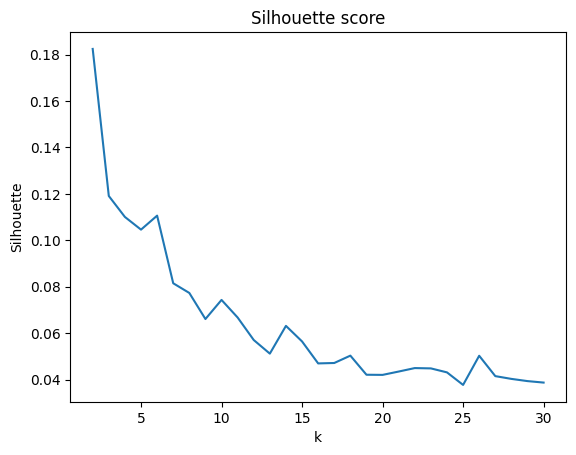

Лучшее k: 2


In [509]:
sil_scores = []
k_range = range(2, 31)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(df)
    sil_scores.append(silhouette_score(df, labels))

plt.figure()
plt.plot(list(k_range), sil_scores)
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette score")
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print("Лучшее k:", best_k)

In [510]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(df)

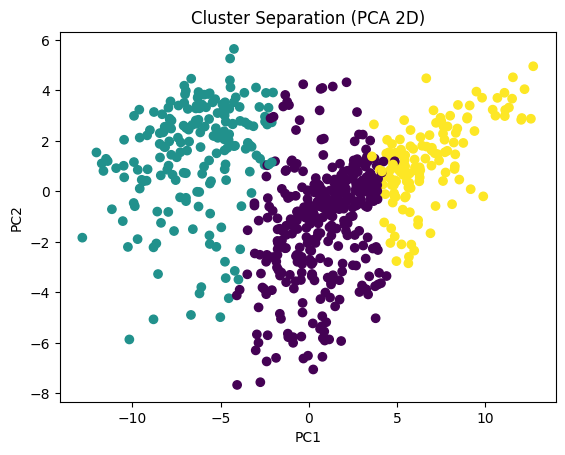

In [511]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Separation (PCA 2D)")
plt.show()

In [512]:
print("Объясненная дисперсия", pca.explained_variance_ratio_.sum())

Explained variance (2 PCs): 0.32110006110225275


## Agglomertive

In [519]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = agg.fit_predict(df)

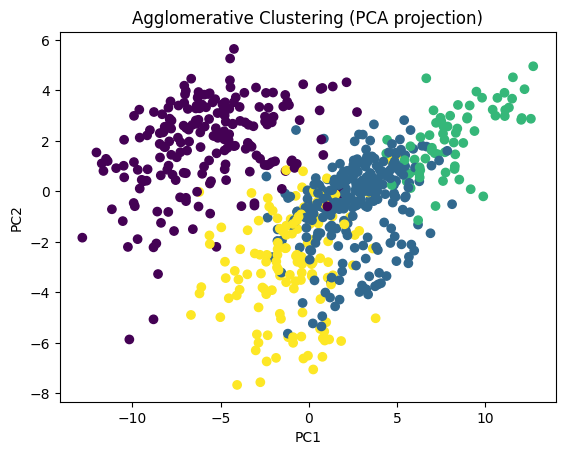

Размеры кластеров: [202 274  69 136]
Объясненная дисперсия: 0.32110006107803934


In [518]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering (PCA projection)")
plt.show()

print("Размеры кластеров:", np.bincount(clusters))
print("Объясненная дисперсия:", pca.explained_variance_ratio_.sum())